In [25]:
from google.colab import files
uploaded=files.upload()

Saving cs-training.csv to cs-training (1).csv


In [26]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Handle Imbalanced Dataset
from imblearn.over_sampling import SMOTE

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [27]:
df = pd.read_csv("cs-training.csv")

In [28]:
df.head()


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [29]:
df.tail()


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0
149999,150000,0,0.850283,64,0,0.249908,8158.0,8,0,2,0,0.0


In [30]:
df.sample(5)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
88118,88119,1,0.830565,53,0,1053.000000,NaN,6,6,0,0,0.0
125924,125925,0,0.765778,38,0,0.801485,3500.0,11,0,2,0,2.0
1542,1543,0,0.000000,30,0,0.149209,3350.0,10,0,0,0,0.0
8158,8159,0,1.000000,56,2,0.230729,13400.0,3,1,2,1,2.0
97346,97347,0,0.127798,46,0,1.663942,1100.0,6,0,1,0,0.0


In [31]:
df.shape


(150000, 12)

In [32]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [33]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [34]:
df.rename(columns={"Unnamed: 0":"ID"}, inplace=True)

In [35]:
df.columns

Index(['ID', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [36]:
df.isnull().sum()

,0
ID,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


In [37]:
(df.isnull().sum()/len(df))*100

,0
ID,0.000000
SeriousDlqin2yrs,0.000000
RevolvingUtilizationOfUnsecuredLines,0.000000
age,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0.000000
DebtRatio,0.000000
MonthlyIncome,19.820667
NumberOfOpenCreditLinesAndLoans,0.000000
NumberOfTimes90DaysLate,0.000000
NumberRealEstateLoansOrLines,0.000000


In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df["SeriousDlqin2yrs"].value_counts()

,count
SeriousDlqin2yrs,
0,139974
1,10026


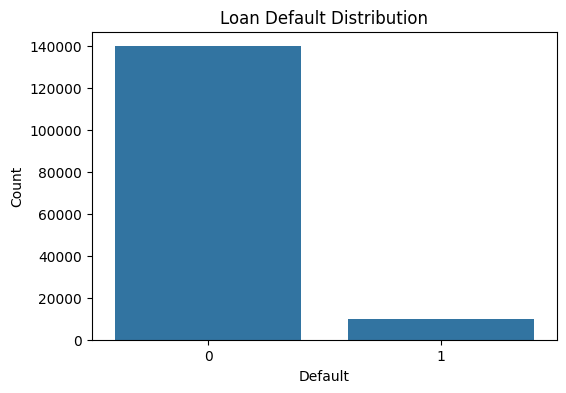

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(x="SeriousDlqin2yrs", data=df)

plt.title("Loan Default Distribution")
plt.xlabel("Default")
plt.ylabel("Count")

plt.show()

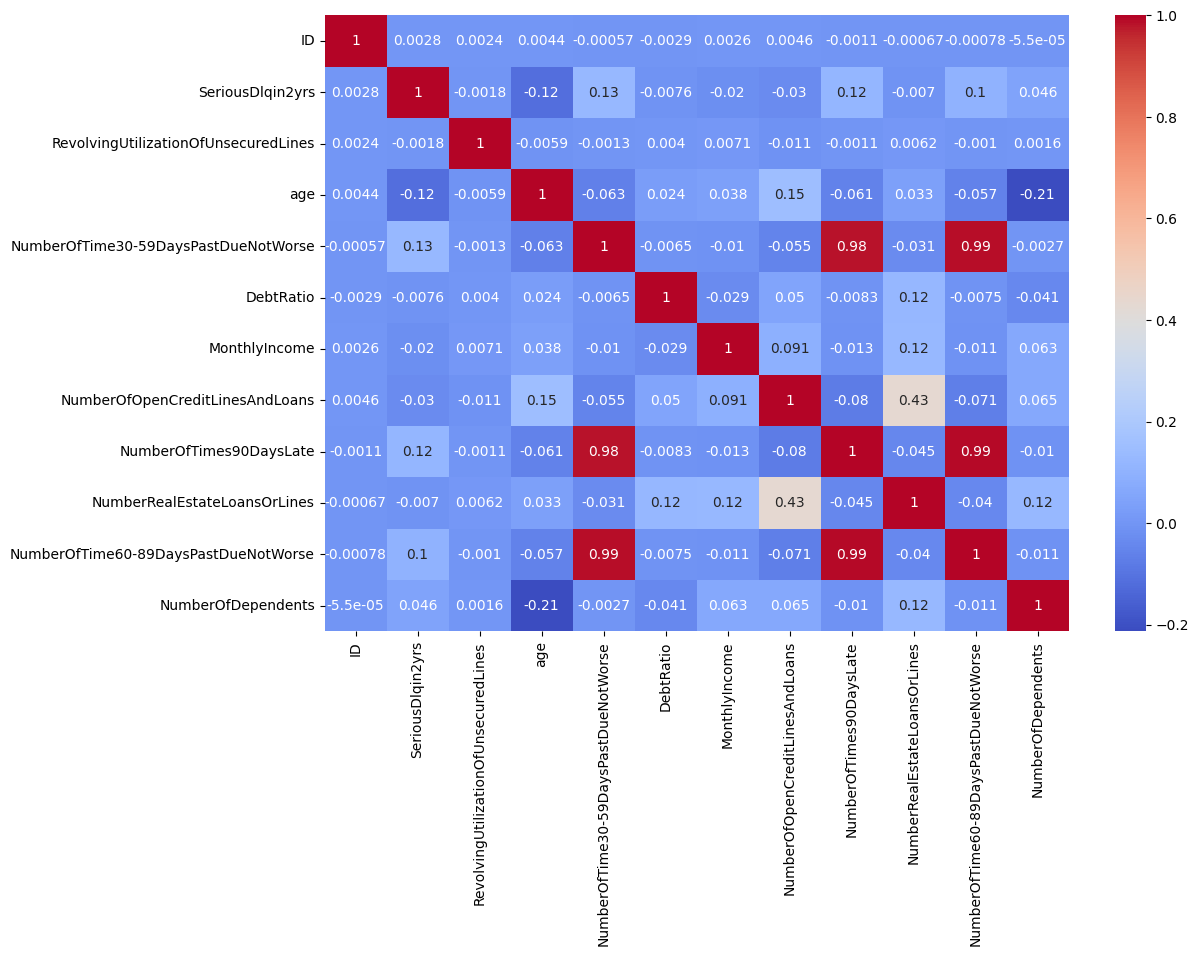

In [41]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

plt.show()

In [42]:
df["MonthlyIncome"].fillna(df["MonthlyIncome"].median(), inplace=True)

In [43]:
df["NumberOfDependents"].fillna(df["NumberOfDependents"].median(), inplace=True)

In [44]:
df.isnull().sum()

,0
ID,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


In [45]:
# Drop ID column and target column
X = df.drop(["ID", "SeriousDlqin2yrs"], axis=1)

# Target variable
y = df["SeriousDlqin2yrs"]

print(X.shape)
print(y.shape)

(150000, 10)
(150000,)


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [49]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [50]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.934


In [51]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.5806451612903226


In [52]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.04488778054862843


In [53]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.08333333333333333


In [54]:
roc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", roc)

ROC AUC: 0.7143274515978317


In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     27995
           1       0.58      0.04      0.08      2005

    accuracy                           0.93     30000
   macro avg       0.76      0.52      0.52     30000
weighted avg       0.91      0.93      0.91     30000



In [56]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[27930    65]
 [ 1915    90]]


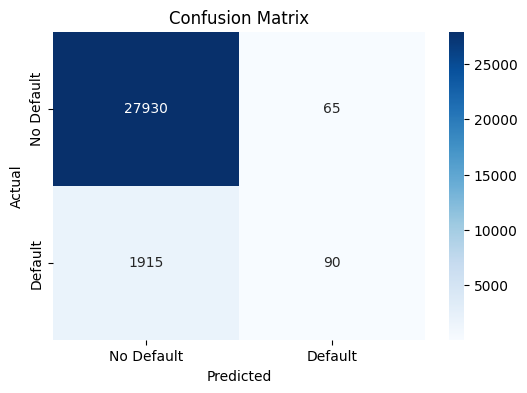

In [57]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

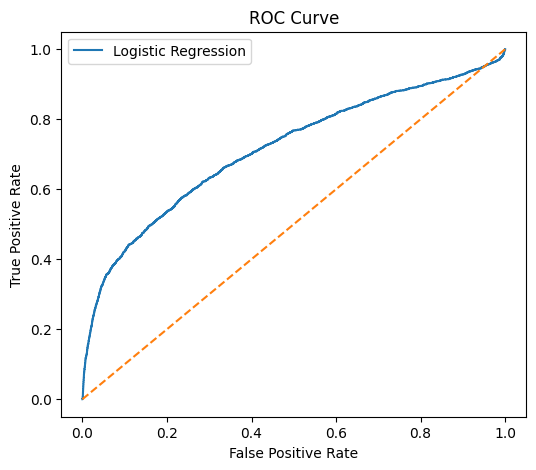

In [58]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [59]:
# Create SMOTE object
smote = SMOTE(random_state=42)

# Generate balanced training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [60]:
print("Before SMOTE")
print(y_train.value_counts())

Before SMOTE
SeriousDlqin2yrs
0    111979
1      8021
Name: count, dtype: int64


In [61]:
print("\nAfter SMOTE")
print(y_train_smote.value_counts())


After SMOTE
SeriousDlqin2yrs
0    111979
1    111979
Name: count, dtype: int64


In [62]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=200, random_state=42)

In [63]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [64]:
print("Accuracy")

print(accuracy_score(y_test, rf_pred))

Accuracy
0.9152666666666667


In [65]:
print("Precision")

print(precision_score(y_test, rf_pred))

print("Recall")

print(recall_score(y_test, rf_pred))

print("F1 Score")

print(f1_score(y_test, rf_pred))

Precision
0.36037441497659906
Recall
0.3456359102244389
F1 Score
0.3528513238289206


In [66]:
print("ROC AUC")

print(roc_auc_score(y_test, rf_prob))


ROC AUC
0.8262348593599053


In [67]:

print(classification_report(y_test, rf_pred))



              precision    recall  f1-score   support

           0       0.95      0.96      0.95     27995
           1       0.36      0.35      0.35      2005

    accuracy                           0.92     30000
   macro avg       0.66      0.65      0.65     30000
weighted avg       0.91      0.92      0.91     30000



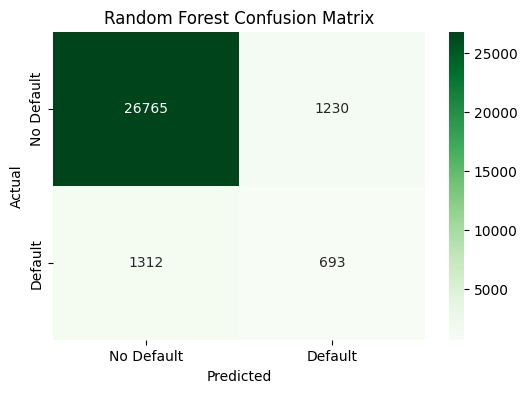

In [68]:

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Greens",
    xticklabels=["No Default","Default"],
    yticklabels=["No Default","Default"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

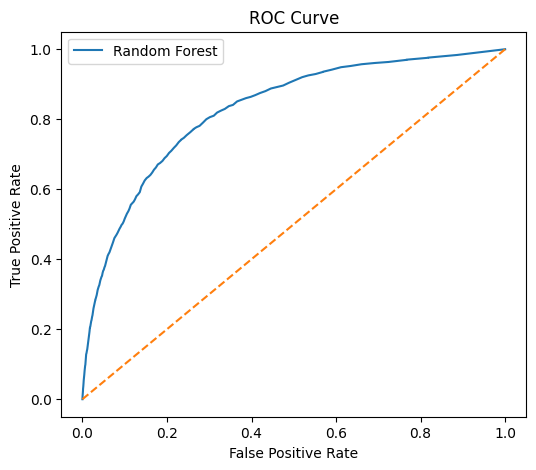

In [69]:

fpr,tpr,threshold=roc_curve(y_test,rf_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [70]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,rf_pred)
    ],

    "Precision":[
        precision_score(y_test,y_pred),
        precision_score(y_test,rf_pred)
    ],

    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,rf_pred)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred),
        f1_score(y_test,rf_pred)
    ],

    "ROC AUC":[
        roc_auc_score(y_test,y_prob),
        roc_auc_score(y_test,rf_prob)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.934000,0.580645,0.044888,0.083333,0.714327
1,Random Forest,0.915267,0.360374,0.345636,0.352851,0.826235


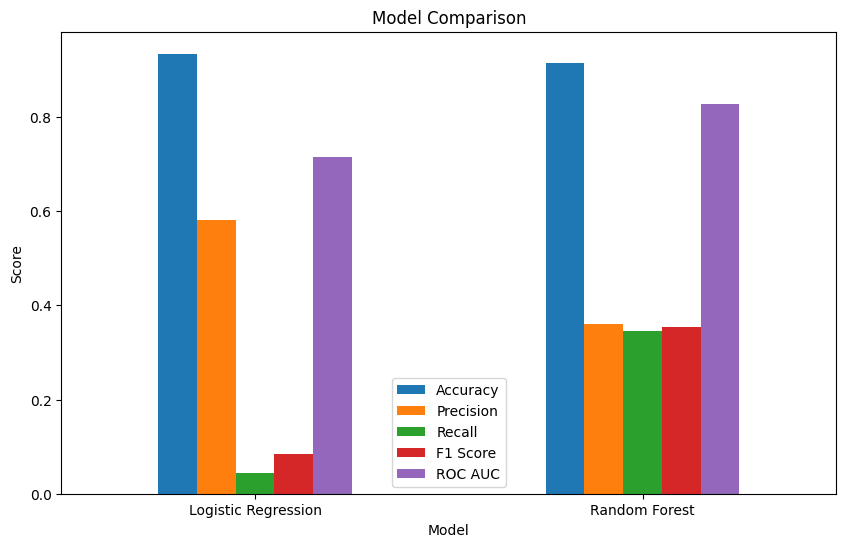

In [71]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

In [72]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,RevolvingUtilizationOfUnsecuredLines,0.231775
2,NumberOfTime30-59DaysPastDueNotWorse,0.160068
1,age,0.113087
6,NumberOfTimes90DaysLate,0.106533
3,DebtRatio,0.094097
5,NumberOfOpenCreditLinesAndLoans,0.090197
4,MonthlyIncome,0.086204
8,NumberOfTime60-89DaysPastDueNotWorse,0.067970
7,NumberRealEstateLoansOrLines,0.025261
9,NumberOfDependents,0.024808


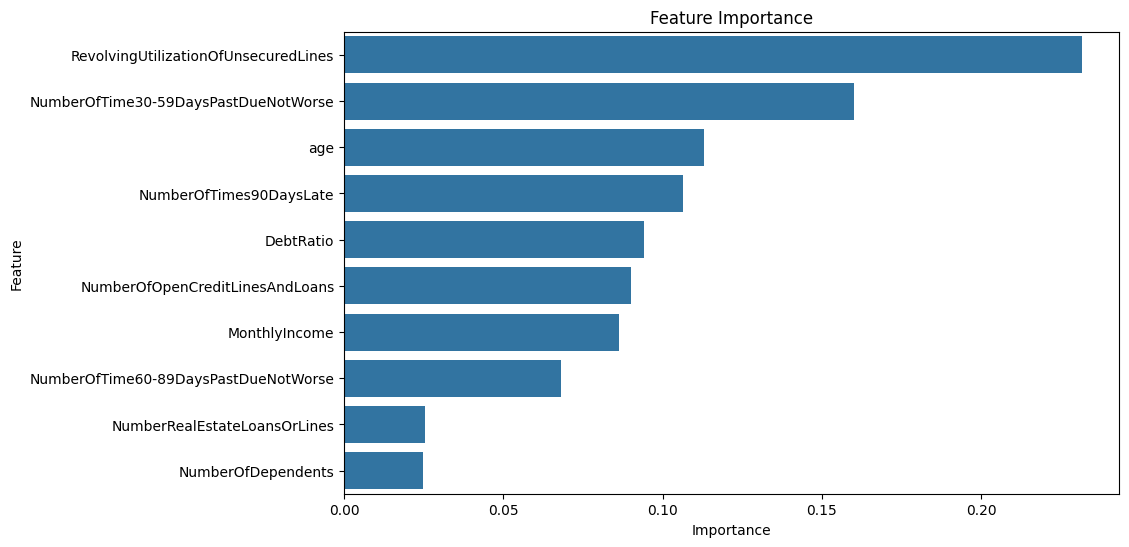

In [73]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [74]:
joblib.dump(rf,"loan_default_model.pkl")

['loan_default_model.pkl']

In [75]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [76]:
model = joblib.load("loan_default_model.pkl")